<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EA%B9%80%EC%8B%9C%EC%9A%B0/Leaf(Random_Forest).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 1. IMPORT
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

In [2]:
# ============================================================
# 2. SETTINGS
# ============================================================
CSV_FILENAME = "merged_features.csv"
TARGET = "soh_label_pct"

N_SPLITS = 5
N_ESTIMATORS = 500
SEED = 42
PERMUTATION_REPEATS = 30

In [4]:
# ============================================================
# 3. DATA LOAD
# ============================================================
df = pd.read_csv(CSV_FILENAME)

X = df.drop(columns=[TARGET])
y = df[TARGET]

FEATURES = X.columns.tolist()
X_ALL = X.to_numpy(dtype=np.float32)
Y_ALL = y.to_numpy(dtype=np.float32)

In [5]:
# ============================================================
# 4. RANDOM FOREST MODEL
# ============================================================
def make_model(seed):
    return RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        random_state=seed,
        n_jobs=-1
    )

In [6]:
# ============================================================
# 5. 5-FOLD CROSS VALIDATION
# ============================================================
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_prediction = np.zeros(len(Y_ALL), dtype=np.float32)
fold_models = []
fold_indices = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_ALL)):
    X_train = X_ALL[train_idx]
    X_val = X_ALL[val_idx]
    y_train = Y_ALL[train_idx]

    model = make_model(SEED + fold)
    model.fit(X_train, y_train)

    oof_prediction[val_idx] = model.predict(X_val)

    fold_models.append(model)
    fold_indices.append({"train": train_idx, "val": val_idx})

In [7]:
# ============================================================
# 6. MODEL PERFORMANCE
# ============================================================
MSE = mean_squared_error(Y_ALL, oof_prediction)
MAE = mean_absolute_error(Y_ALL, oof_prediction)
R2 = r2_score(Y_ALL, oof_prediction)

error_rate = (np.abs(Y_ALL - oof_prediction) / np.abs(Y_ALL)) * 100

print(f"MSE     : {MSE:.6f}")
print(f"MAE     : {MAE:.6f}")
print(f"R-score : {R2:.6f}")

print("\nError Rate Stats")
print(f"Mean    : {np.mean(error_rate):.4f}%")
print(f"Median  : {np.median(error_rate):.4f}%")
print(f"Std     : {np.std(error_rate):.4f}%")
print(f"Min     : {np.min(error_rate):.4f}%")
print(f"Max     : {np.max(error_rate):.4f}%")
print(f"95%     : {np.percentile(error_rate, 95):.4f}%")

MSE     : 0.662036
MAE     : 0.454992
R-score : 0.985623

Error Rate Stats
Mean    : 0.5203%
Median  : 0.3642%
Std     : 0.7639%
Min     : 0.0000%
Max     : 6.3098%
95%     : 1.4851%


In [8]:
# ============================================================
# 7. PERMUTATION FEATURE IMPORTANCE
# ============================================================

permutation_scores = []

for fold in range(N_SPLITS):
    val_idx = fold_indices[fold]["val"]
    X_val = X_ALL[val_idx]
    y_val = Y_ALL[val_idx]
    model = fold_models[fold]

    result = permutation_importance(
        model,
        X_val,
        y_val,
        scoring="neg_mean_squared_error",
        n_repeats=PERMUTATION_REPEATS,
        random_state=SEED + fold,
        n_jobs=-1
    )

    permutation_scores.append(result.importances_mean)

permutation_scores = np.array(permutation_scores)

In [9]:
# ============================================================
# 8. FEATURE IMPORTANCE DATA
# ============================================================

feature_importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": permutation_scores.mean(axis=0),
    "Std": permutation_scores.std(axis=0)
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=True
).reset_index(drop=True)

In [10]:
# ============================================================
# 9. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = np.mean(
    [model.feature_importances_ for model in fold_models],
    axis=0
)

rf_importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_importance
}).sort_values("Importance", ascending=True)

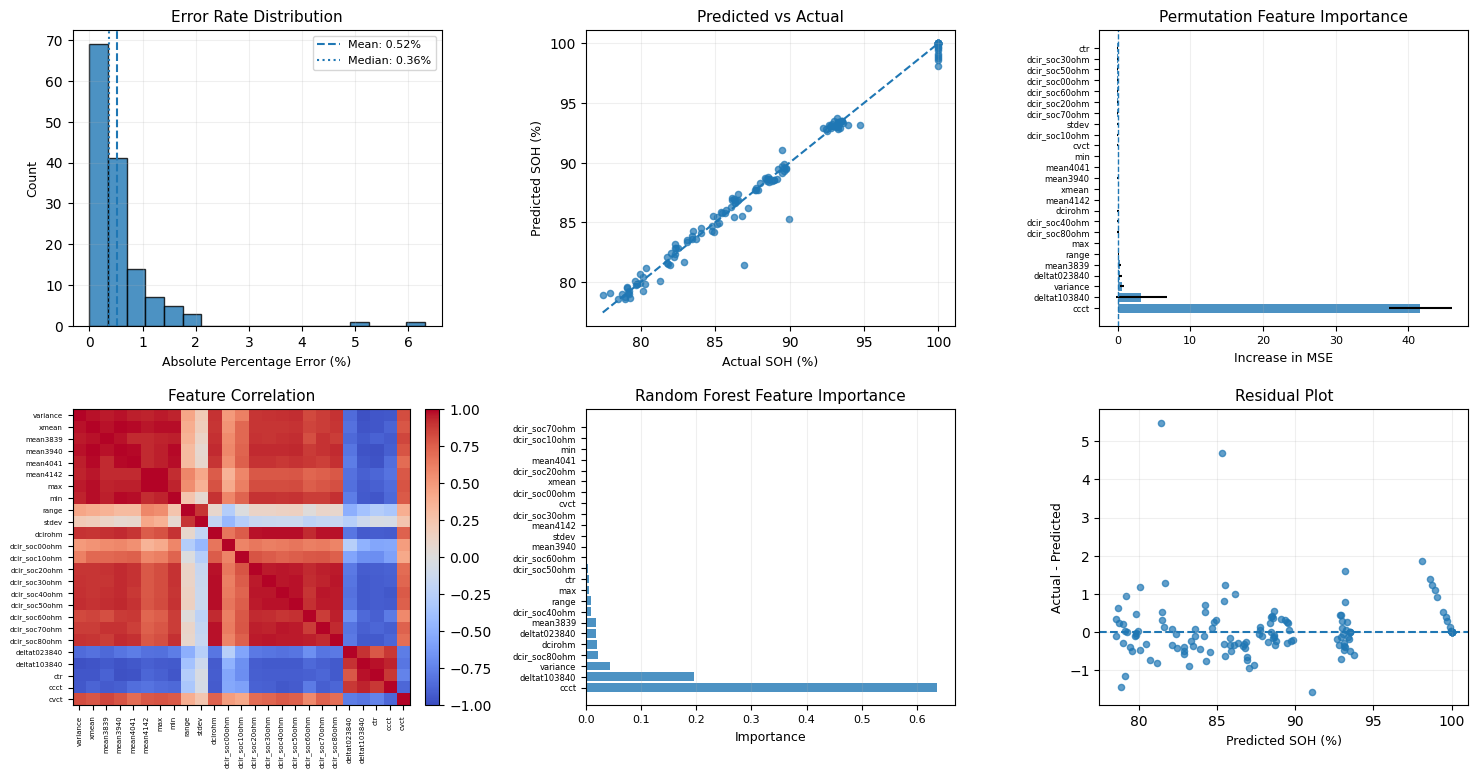

In [11]:
# ============================================================
# 10. VISUALIZATION
# ============================================================

residuals = Y_ALL - oof_prediction
correlation_matrix = X.corr()

plot_importance = feature_importance_df.sort_values("Importance", ascending=True)
plot_rf_importance = rf_importance_df.sort_values("Importance", ascending=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ============================================================
# 1. Error Rate Distribution
# ============================================================
ax = axes[0, 0]

ax.hist(error_rate, bins=18, edgecolor="black", alpha=0.8)
ax.axvline(np.mean(error_rate), linestyle="--", label=f"Mean: {np.mean(error_rate):.2f}%")
ax.axvline(np.median(error_rate), linestyle=":", label=f"Median: {np.median(error_rate):.2f}%")

ax.set_title("Error Rate Distribution", fontsize=11)
ax.set_xlabel("Absolute Percentage Error (%)", fontsize=9)
ax.set_ylabel("Count", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ============================================================
# 2. Predicted vs Actual
# ============================================================
ax = axes[0, 1]

ax.scatter(Y_ALL, oof_prediction, alpha=0.7, s=20)

minimum = min(Y_ALL.min(), oof_prediction.min())
maximum = max(Y_ALL.max(), oof_prediction.max())

ax.plot([minimum, maximum], [minimum, maximum], linestyle="--")
ax.set_title("Predicted vs Actual", fontsize=11)
ax.set_xlabel("Actual SOH (%)", fontsize=9)
ax.set_ylabel("Predicted SOH (%)", fontsize=9)
ax.grid(alpha=0.2)

# ============================================================
# 3. Permutation Feature Importance
# ============================================================
ax = axes[0, 2]

ax.barh(
    plot_importance["Feature"],
    plot_importance["Importance"],
    xerr=plot_importance["Std"],
    alpha=0.8
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Permutation Feature Importance", fontsize=11)
ax.set_xlabel("Increase in MSE", fontsize=9)
ax.tick_params(axis="y", labelsize=6)
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()

# ============================================================
# 4. Correlation Heatmap
# ============================================================
ax = axes[1, 0]

heatmap = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_title("Feature Correlation", fontsize=11)
ax.set_xticks(np.arange(len(FEATURES)))
ax.set_yticks(np.arange(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=90, fontsize=5)
ax.set_yticklabels(FEATURES, fontsize=5)

fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)

# ============================================================
# 5. Random Forest Feature Importance
# ============================================================
ax = axes[1, 1]

ax.barh(
    plot_rf_importance["Feature"],
    plot_rf_importance["Importance"],
    alpha=0.8
)

ax.set_title("Random Forest Feature Importance", fontsize=11)
ax.set_xlabel("Importance", fontsize=9)
ax.tick_params(axis="y", labelsize=6)
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()

# ============================================================
# 6. Residual Plot
# ============================================================
ax = axes[1, 2]

ax.scatter(oof_prediction, residuals, alpha=0.7, s=20)
ax.axhline(0, linestyle="--")

ax.set_title("Residual Plot", fontsize=11)
ax.set_xlabel("Predicted SOH (%)", fontsize=9)
ax.set_ylabel("Actual - Predicted", fontsize=9)
ax.grid(alpha=0.2)

# ============================================================
# Layout
# ============================================================
plt.tight_layout(pad=1.5)
plt.show()